# ISIS `shadow` cast-shadow modeling spike

Spike for `docs/proposed-tasks/isis-shadow-masking.md`'s "Recommended sequencing" step 1: convert
one real candidate's hole-filled DEM (elevation -> radius, GeoTIFF -> ISIS cube), run `demprep`,
then ISIS `shadow` with `SUNPOSITIONSOURCE=TIME` against the candidate's own real acquisition
ephemeris time, reusing this project's already-cached PCK/SPK kernels -- no new kernel fetch.

Disposable, kept for reference rather than deleted -- not imported by anything. See that doc's
"Open questions" section for what each step below needed in practice (an `editlab` patch for a
missing Mapping group field, and a text-vs-binary PCK gotcha).

In [1]:
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import spiceypy as spice
from matplotlib.colors import LightSource

import trntest
from trntest import cache, dem_ortho, illumination
from trntest.config import MOON_RADIUS_M
from trntest.subprocess_utils import run_quiet

# Lowest sun_elevation_deg row in dataset_manifest.csv (13.6 deg) -- report.problem_flags' own
# "deep shadow risk" threshold, so this candidate is the best real-shadow validation case available
# in the current manifest (see isis-shadow-masking.md's "Recommended sequencing" step 2).
CANDIDATE_PRODUCT_ID = "M1327218454CE"


def catlab(cub_path: Path) -> str:
    result = subprocess.run(["catlab", f"from={cub_path}"], capture_output=True, text=True, check=False)
    print(result.stdout)
    if result.stderr:
        print("--- stderr ---")
        print(result.stderr)
    return result.stdout

## Candidate and DEM

Reuses `dem_ortho.fetch_dem` directly (not the full `fetch_dem_and_ortho`) -- the ortho texture
isn't needed for this spike, only the hole-filled DEM `despeckle_and_shade_ortho` shades on.

In [2]:
session = trntest.Session()
config = session.config

images = trntest.read_manifest("dataset_manifest.csv")
dataset = trntest.TrnTestDataSet.create(config.output_dir / "trn_dataset", images, config)
entry = dataset[CANDIDATE_PRODUCT_ID]
camera = entry.camera
print(f"candidate: {entry.edr_product}, footprint center (lon,lat): {camera.footprint_lonlat_deg['center']}")
print(f"camera.et (TDB seconds): {camera.et}")

candidate: M1327218454CE, footprint center (lon,lat): (np.float64(177.77785856883), np.float64(73.514130051066))
camera.et (TDB seconds): 625851375.1071182


In [3]:
dem_result = dem_ortho.fetch_dem(camera, entry.config)
print(f"DEM: {dem_result.dem}, bbox={dem_result.bbox}, {dem_result.width}x{dem_result.height}")

spike_dir = config.scratch_dir / "isis_shadow_spike"
spike_dir.mkdir(parents=True, exist_ok=True)

ROI center (lon,lat deg): (np.float64(177.77785856883), np.float64(73.514130051066)), bbox (local m): (-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701)
ROI size 2424x2437 px (~100.0 m/px)


DEM: /workspace/output/dem_filled-tile-0.tif, bbox=(-116630.64254994773, -116890.0616343932, 125768.49282831521, 126767.40375456701), 2424x2437


## Elevation -> radius, GeoTIFF -> ISIS cube

`shadow`/`demprep` need radius-as-DN, not elevation -- a plain `elevation_m + MOON_RADIUS_M` add.
`gdal_translate -of ISIS3` turns out to produce a genuinely valid ISIS `Mapping` group directly
from this project's local-Orthographic PROJ4 string (`TargetName=MOON`, correct
`CenterLongitude`/`CenterLatitude`/`EquatorialRadius`/`PolarRadius`) -- no manual label
construction needed for those fields.

In [4]:
radius_tif = spike_dir / f"{entry.edr_product}_dem_radius.tif"
with rasterio.open(dem_result.dem) as src:
    elevation = src.read(1)
    profile = src.profile
radius = (elevation.astype("float64") + MOON_RADIUS_M).astype("float32")
print(f"radius range: min={radius.min():.1f} max={radius.max():.1f} (MOON_RADIUS_M={MOON_RADIUS_M})")
profile.update(dtype="float32")
radius_tif.unlink(missing_ok=True)
with rasterio.open(radius_tif, "w", **profile) as dst:
    dst.write(radius, 1)
print(f"radius GeoTIFF written: {radius_tif}")

radius range: min=1732274.0 max=1740602.0 (MOON_RADIUS_M=1737400.0)


radius GeoTIFF written: /workspace/scratch/isis_shadow_spike/M1327218454CE_dem_radius.tif


In [5]:
radius_cub = spike_dir / f"{entry.edr_product}_dem_radius.cub"
radius_cub.unlink(missing_ok=True)
run_quiet(["gdal_translate", "-of", "ISIS3", str(radius_tif), str(radius_cub)])
print("=== catlab after gdal_translate -of ISIS3 ===")
catlab(radius_cub)

=== catlab after gdal_translate -of ISIS3 ===


Object = IsisCube
  Object = Core
    StartByte = 65537
    Format    = BandSequential

    Group = Dimensions
      Samples = 2424
      Lines   = 2437
      Bands   = 1
    End_Group

    Group = Pixels
      Type       = Real
      ByteOrder  = Lsb
      Base       = 0.0
      Multiplier = 1.0
    End_Group
  End_Object

  Group = Mapping
    TargetName         = MOON
    EquatorialRadius   = 1737400.0 <meters>
    PolarRadius        = 1737400.0 <meters>
    LatitudeType       = Planetocentric
    LongitudeDirection = PositiveEast
    LongitudeDomain    = 180
    ProjectionName     = Orthographic
    CenterLongitude    = 177.77785856883
    CenterLatitude     = 73.514130051066005
  End_Group
End_Object

Object = Label
  Bytes = 65536
End_Object

Object = History
  Name      = IsisCube
  StartByte = 23694689
  Bytes     = 346
End_Object
End

--- stderr ---
Detected locale "C" with character encoding "ANSI_X3.4-1968", which is not UTF-8.
Qt depends on a UTF-8 locale, and has switched 

'Object = IsisCube\n  Object = Core\n    StartByte = 65537\n    Format    = BandSequential\n\n    Group = Dimensions\n      Samples = 2424\n      Lines   = 2437\n      Bands   = 1\n    End_Group\n\n    Group = Pixels\n      Type       = Real\n      ByteOrder  = Lsb\n      Base       = 0.0\n      Multiplier = 1.0\n    End_Group\n  End_Object\n\n  Group = Mapping\n    TargetName         = MOON\n    EquatorialRadius   = 1737400.0 <meters>\n    PolarRadius        = 1737400.0 <meters>\n    LatitudeType       = Planetocentric\n    LongitudeDirection = PositiveEast\n    LongitudeDomain    = 180\n    ProjectionName     = Orthographic\n    CenterLongitude    = 177.77785856883\n    CenterLatitude     = 73.514130051066005\n  End_Group\nEnd_Object\n\nObject = Label\n  Bytes = 65536\nEnd_Object\n\nObject = History\n  Name      = IsisCube\n  StartByte = 23694689\n  Bytes     = 346\nEnd_Object\nEnd\n'

## Patch the missing Mapping fields

`gdal_translate`'s Mapping group omits `PixelResolution`/`UpperLeftCornerX`/`UpperLeftCornerY` --
`demprep`'s projection-init fails outright without them (`**ERROR** PVL Keyword [PixelResolution]
does not exist in [Group = Mapping]`). Patched in via `editlab`, computed from this DEM's own
`bbox`/resolution (the same values `dem_ortho.fetch_dem` already returned above, not re-derived).

In [6]:
minx, miny, maxx, maxy = dem_result.bbox
pixel_resolution_m = (maxx - minx) / dem_result.width
for keyword, value in (
    ("PixelResolution", pixel_resolution_m),
    ("UpperLeftCornerX", minx),
    ("UpperLeftCornerY", maxy),  # row 0 = north/top, matches hapke._terrain_photometric_angles' convention
):
    run_quiet(
        ["editlab", f"from={radius_cub}", "options=addkey", "grpname=Mapping", f"keyword={keyword}", f"value={value}"]
    )
print("=== catlab after editlab patch ===")
catlab(radius_cub)

=== catlab after editlab patch ===
Object = IsisCube
  Object = Core
    StartByte = 65537
    Format    = BandSequential

    Group = Dimensions
      Samples = 2424
      Lines   = 2437
      Bands   = 1
    End_Group

    Group = Pixels
      Type       = Real
      ByteOrder  = Lsb
      Base       = 0.0
      Multiplier = 1.0
    End_Group
  End_Object

  Group = Mapping
    ProjectionName     = Orthographic
    CenterLongitude    = 177.77785856883
    TargetName         = MOON
    EquatorialRadius   = 1737400.0 <meters>
    PolarRadius        = 1737400.0 <meters>
    LatitudeType       = Planetocentric
    LongitudeDirection = PositiveEast
    LongitudeDomain    = 180
    UpperLeftCornerX   = -116630.64254994773
    UpperLeftCornerY   = 126767.40375456701
    PixelResolution    = 99.99964330786426
    CenterLatitude     = 73.514130051066005
  End_Group
End_Object

Object = Label
  Bytes = 65536
End_Object

Object = History
  Name      = IsisCube
  StartByte = 23694689
  Bytes    

'Object = IsisCube\n  Object = Core\n    StartByte = 65537\n    Format    = BandSequential\n\n    Group = Dimensions\n      Samples = 2424\n      Lines   = 2437\n      Bands   = 1\n    End_Group\n\n    Group = Pixels\n      Type       = Real\n      ByteOrder  = Lsb\n      Base       = 0.0\n      Multiplier = 1.0\n    End_Group\n  End_Object\n\n  Group = Mapping\n    ProjectionName     = Orthographic\n    CenterLongitude    = 177.77785856883\n    TargetName         = MOON\n    EquatorialRadius   = 1737400.0 <meters>\n    PolarRadius        = 1737400.0 <meters>\n    LatitudeType       = Planetocentric\n    LongitudeDirection = PositiveEast\n    LongitudeDomain    = 180\n    UpperLeftCornerX   = -116630.64254994773\n    UpperLeftCornerY   = 126767.40375456701\n    PixelResolution    = 99.99964330786426\n    CenterLatitude     = 73.514130051066005\n  End_Group\nEnd_Object\n\nObject = Label\n  Bytes = 65536\nEnd_Object\n\nObject = History\n  Name      = IsisCube\n  StartByte = 23694689\n  B

## `demprep`

Pads poles (skipped here: this AOI is a small local-Orthographic crop, not a global Simple
Cylindrical DEM -- per `demprep`'s own docs this should just skip padding rather than fail) and
attaches the `ShapeModelStatistics` table blob `shadow` needs (min/max radii in the DEM).

In [7]:
demprep_cub = spike_dir / f"{entry.edr_product}_dem_radius.demprep.cub"
demprep_cub.unlink(missing_ok=True)
run_quiet(["demprep", f"from={radius_cub}", f"to={demprep_cub}"])
print("=== catlab after demprep ===")
catlab(demprep_cub)

=== catlab after demprep ===
Object = IsisCube
  Object = Core
    StartByte = 65537
    Format    = BandSequential

    Group = Dimensions
      Samples = 2424
      Lines   = 2437
      Bands   = 1
    End_Group

    Group = Pixels
      Type       = Real
      ByteOrder  = Lsb
      Base       = 0.0
      Multiplier = 1.0
    End_Group
  End_Object

  Group = Mapping
    ProjectionName     = Orthographic
    CenterLongitude    = 177.77785856883
    TargetName         = MOON
    EquatorialRadius   = 1737400.0 <meters>
    PolarRadius        = 1737400.0 <meters>
    LatitudeType       = Planetocentric
    LongitudeDirection = PositiveEast
    LongitudeDomain    = 180
    UpperLeftCornerX   = -116630.64254994773
    UpperLeftCornerY   = 126767.40375456701
    PixelResolution    = 99.99964330786426
    CenterLatitude     = 73.514130051066005
  End_Group
End_Object

Object = Label
  Bytes = 65536
End_Object

Object = Table
  Name      = ShapeModelStatistics
  StartByte = 23697479
  Bytes

'Object = IsisCube\n  Object = Core\n    StartByte = 65537\n    Format    = BandSequential\n\n    Group = Dimensions\n      Samples = 2424\n      Lines   = 2437\n      Bands   = 1\n    End_Group\n\n    Group = Pixels\n      Type       = Real\n      ByteOrder  = Lsb\n      Base       = 0.0\n      Multiplier = 1.0\n    End_Group\n  End_Object\n\n  Group = Mapping\n    ProjectionName     = Orthographic\n    CenterLongitude    = 177.77785856883\n    TargetName         = MOON\n    EquatorialRadius   = 1737400.0 <meters>\n    PolarRadius        = 1737400.0 <meters>\n    LatitudeType       = Planetocentric\n    LongitudeDirection = PositiveEast\n    LongitudeDomain    = 180\n    UpperLeftCornerX   = -116630.64254994773\n    UpperLeftCornerY   = 126767.40375456701\n    PixelResolution    = 99.99964330786426\n    CenterLatitude     = 73.514130051066005\n  End_Group\nEnd_Object\n\nObject = Label\n  Bytes = 65536\nEnd_Object\n\nObject = Table\n  Name      = ShapeModelStatistics\n  StartByte = 236

## `shadow`

`SUNPOSITIONSOURCE=TIME` against this candidate's own real acquisition ET. Uses `pck00010.tpc`
(the plain **text** PCK, direct IAU_MOON RA/DEC/W polynomial), not the higher-precision binary
`moon_pa_de421_1900_2050.bpc`: a first attempt with the binary PCK crashed `shadow` with
`SPICE(FRAMEDATANOTFOUND) ... required to compute the orientation of the body-fixed frame
IAU_MOON` -- the binary PCK only provides the `MOON_PA` frame, which needs the extra
`moon_assoc_me.tf`/`moon_080317.tf` frame-kernel association this project's Python side furnishes
alongside it (`spice_kernels.ALWAYS_KERNELS`), but `shadow`'s single `PCK=` parameter has no slot
for a second file. `shadow` wants plain `IAU_MOON` directly, which the text PCK alone provides.
Both kernels are already cached (`spice_kernels.ALWAYS_KERNELS`) -- no new fetch.

In [8]:
utc_time = spice.et2utc(camera.et, "ISOC", 3)
print(f"candidate acquisition time (UTC, from camera.et via spiceypy): {utc_time}")

pck_path = cache.fetch_naif_kernel("data/pck/pck00010.tpc", cache_root=config.cache_root, base_url=config.naif_base_url)
spk_path = cache.fetch_naif_kernel("data/spk/de421.bsp", cache_root=config.cache_root, base_url=config.naif_base_url)
print(f"PCK: {pck_path}\nSPK: {spk_path}")

shadow_cub = spike_dir / f"{entry.edr_product}_dem_radius.shadow.cub"
shadow_cub.unlink(missing_ok=True)
run_quiet(
    [
        "shadow",
        f"from={demprep_cub}",
        f"to={shadow_cub}",
        "sunpositionsource=time",
        f"time={utc_time}",
        f"pck={pck_path}",
        f"spk={spk_path}",
    ]
)
print("=== catlab after shadow ===")
catlab(shadow_cub)
run_quiet(["stats", f"from={shadow_cub}"])

candidate acquisition time (UTC, from camera.et via spiceypy): 2019-11-01T03:35:05.925
PCK: /workspace/cache/naif/lro-l-spice-6-v1.0/lrosp_1000/data/pck/pck00010.tpc
SPK: /workspace/cache/naif/lro-l-spice-6-v1.0/lrosp_1000/data/spk/de421.bsp


=== catlab after shadow ===
Object = IsisCube
  Object = Core
    StartByte = 65537
    Format    = BandSequential

    Group = Dimensions
      Samples = 2424
      Lines   = 2437
      Bands   = 1
    End_Group

    Group = Pixels
      Type       = Real
      ByteOrder  = Lsb
      Base       = 0.0
      Multiplier = 1.0
    End_Group
  End_Object

  Group = Mapping
    ProjectionName     = Orthographic
    CenterLongitude    = 177.77785856883
    TargetName         = MOON
    EquatorialRadius   = 1737400.0 <meters>
    PolarRadius        = 1737400.0 <meters>
    LatitudeType       = Planetocentric
    LongitudeDirection = PositiveEast
    LongitudeDomain    = 180
    UpperLeftCornerX   = -116630.64254994773
    UpperLeftCornerY   = 126767.40375456701
    PixelResolution    = 99.99964330786426
    CenterLatitude     = 73.514130051066005
  End_Group
End_Object

Object = Label
  Bytes = 65536
End_Object

Object = Table
  Name      = ShapeModelStatistics
  StartByte = 23694689
  Bytes 

## Visual sanity check

Does the shadow mask line up with real terrain features (crater rims/floors), not just noise?
Overlay the LRS mask on a plain Lambertian hillshade of the same DEM (`matplotlib`'s `LightSource`,
not `hapke.shade_ortho` itself -- no ortho texture fetch needed for this check).

In [9]:
shadow_tif = spike_dir / f"{entry.edr_product}_dem_radius.shadow.tif"
shadow_tif.unlink(missing_ok=True)
run_quiet(["gdal_translate", str(shadow_cub), str(shadow_tif)])
with rasterio.open(shadow_tif) as src:
    shadow_val = src.read(1, masked=True)  # ISIS special pixels (LRS here) round-trip through a plain
    # GeoTIFF as the float32 sentinel -3.4028227e+38 (gdalinfo's own "NoData Value"), not NaN --
    # masked=True reads that back via the band's own NoData metadata instead of a bare np.isfinite
    # check, which silently missed every shadowed pixel (a real finite float, just an out-of-range
    # sentinel) on the first pass through this script.
is_shadowed = np.ma.getmaskarray(shadow_val)
print(f"shadowed fraction (of full raster incl. any NULL border): {is_shadowed.mean():.3f}")

shadowed fraction (of full raster incl. any NULL border): 0.179


sun azimuth/elevation at footprint center: 224.44 / 13.32 deg


wrote /workspace/scratch/isis_shadow_spike/M1327218454CE_shadow_spike.png


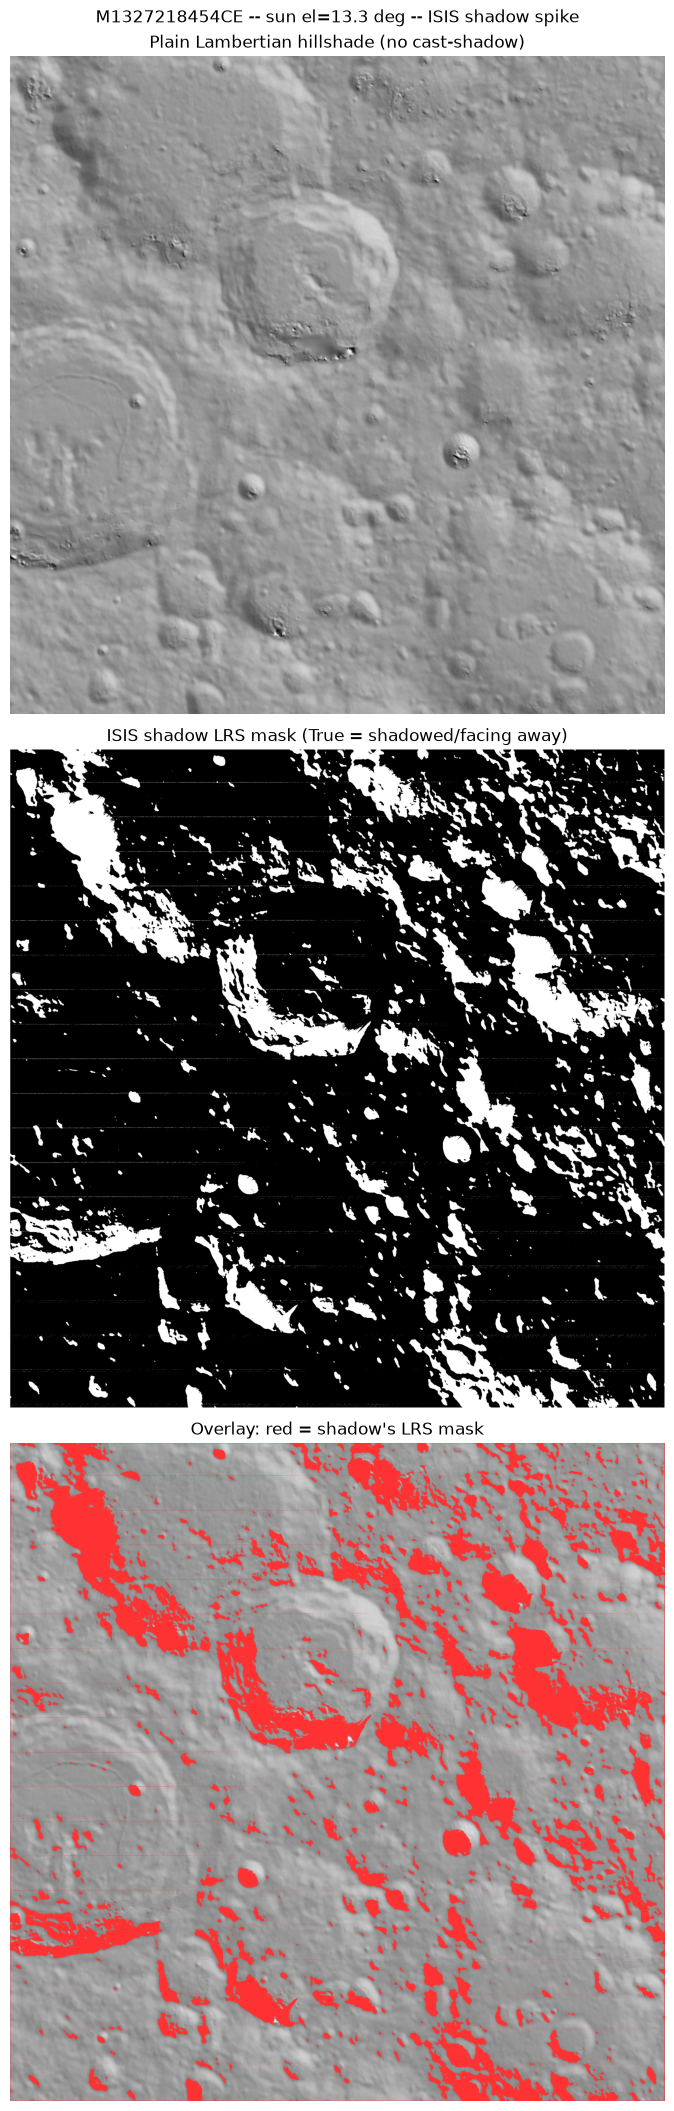

In [10]:
azimuth_deg, elevation_deg = illumination.sun_azimuth_elevation_deg(*camera.footprint_lonlat_deg["center"], camera.et)
print(f"sun azimuth/elevation at footprint center: {azimuth_deg:.2f} / {elevation_deg:.2f} deg")
light = LightSource(azdeg=azimuth_deg, altdeg=elevation_deg)
plain_hillshade = light.hillshade(elevation.astype(np.float64), dx=pixel_resolution_m, dy=pixel_resolution_m)

fig, axes = plt.subplots(3, 1, figsize=(9, 21), constrained_layout=True)
axes[0].imshow(plain_hillshade, cmap="gray")
axes[0].set_title("Plain Lambertian hillshade (no cast-shadow)")
axes[1].imshow(is_shadowed, cmap="gray")
axes[1].set_title("ISIS shadow LRS mask (True = shadowed/facing away)")
overlay = np.stack([plain_hillshade] * 3, axis=-1)
overlay[is_shadowed] = [1.0, 0.2, 0.2]
axes[2].imshow(overlay)
axes[2].set_title("Overlay: red = shadow's LRS mask")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"{entry.edr_product} -- sun el={elevation_deg:.1f} deg -- ISIS shadow spike")
png_path = spike_dir / f"{entry.edr_product}_shadow_spike.png"
fig.savefig(png_path, dpi=150)
print(f"wrote {png_path}")